# Sideview glancing-incidence silicon slab

This notebook builds a sideview Fresnel prototype using an abTEM Lobato silicon potential tiled into a large ideal slab. The final plot shows the propagated slice intensity with atom positions, the final-column intensity, and the positive-angle far field of the full exit wave.


In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd()
if not (repo_root / "wide_angle_propagation").is_dir():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

import abtem
from ase.build import bulk
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from wide_angle_propagation.propagation_methods import (
    energy2wavelength,
    phase_grating_1d_from_projected_potential,
    simulate_glancing_fresnel_baseline_1d,
)

abtem.config.set({"device": "cpu"})
abtem.config.set({"precision": "float64"})
jax.config.update("jax_enable_x64", True)

## Geometry and abTEM silicon unit cell


In [2]:
energy = 30e3

# Real-space slab controls. 100 nm x 20 nm is the requested physical scale.
slab_width_nm = 100.0
slab_depth_nm = 20.0
slab_width_A = 10.0 * slab_width_nm
slab_depth_A = 10.0 * slab_depth_nm
u_margin_A = 120.0

# Lower glancing incidence; the input height is computed so the beam reaches u=0 halfway through the slab.
glancing_angle_degrees = 2.0
glancing_angle = jnp.deg2rad(glancing_angle_degrees)
input_beam_tilt = -glancing_angle
beam_waist = 3.0

# Build one cubic Si diamond unit-cell sideview potential with abTEM/Lobato.
si_lattice_A = 5.431
si_unit = bulk("Si", "diamond", a=si_lattice_A, cubic=True)
si_unit.pbc = [True, True, True]
projection_thickness_A = float(si_unit.cell.lengths()[1])
abtem_sampling_A = 0.5

si_potential = abtem.Potential(
    si_unit,
    sampling=abtem_sampling_A,
    slice_thickness=projection_thickness_A,
    projection="finite",
    parametrization="lobato",
    plane="xz",
    device="cpu",
)
si_unit_projected = np.asarray(si_potential.build(lazy=False).array)[0] / projection_thickness_A
unit_du, unit_ds = (float(v) for v in si_potential.sampling)

# Native slice-stack coordinates: s is propagation path coordinate, u is local transverse coordinate.
du = unit_du
path_step = unit_ds
wavelength_A = float(energy2wavelength(energy))
tilt_frequency = float(jnp.sin(jnp.abs(input_beam_tilt)) / wavelength_A)
nyquist_frequency = 1.0 / (2.0 * du)
tilt_nyquist_fraction = tilt_frequency / nyquist_frequency
n_steps = int(np.ceil(slab_width_A / path_step))
n_u = int(np.ceil((slab_depth_A + 2.0 * u_margin_A) / du))
if n_u % 2:
    n_u += 1
u = (jnp.arange(n_u) - n_u // 2) * du
slice_axis = np.arange(n_steps) * path_step

target_atom_u = 0.0
target_path_coordinate = 0.5 * n_steps * path_step
input_beam_center_u = target_atom_u - target_path_coordinate * jnp.tan(input_beam_tilt)

{
    "unit_potential_shape": si_unit_projected.shape,
    "unit_sampling_A": (unit_du, unit_ds),
    "tilt_nyquist_fraction": tilt_nyquist_fraction,
    "slab_grid_shape": (n_steps, n_u),
    "input_beam_center_u_A": float(input_beam_center_u),
}

{'unit_potential_shape': (11, 11),
 'unit_sampling_A': (0.49372727272727274, 0.49372727272727274),
 'tilt_nyquist_fraction': 0.49378512675600306,
 'slab_grid_shape': (2026, 892),
 'input_beam_center_u_A': 17.465473654373437}

## Tiled slab potential and Fresnel wavefronts


In [3]:
def tile_to_shape(array, shape):
    reps = tuple(int(np.ceil(target / size)) for target, size in zip(shape, array.shape))
    slices = tuple(slice(0, target) for target in shape)
    return np.tile(array, reps)[slices]

# The abTEM unit array is indexed as (u, s). Place the Si slab with its top surface at u=0 and vacuum above it.
n_slab_u = int(np.ceil(slab_depth_A / du))
if n_slab_u % 2:
    n_slab_u += 1
u_grid_np = np.asarray(u)
u_stop = int(np.searchsorted(u_grid_np, 0.0, side="right"))
u_start = u_stop - n_slab_u
if u_start < 0:
    raise ValueError("u grid is not tall enough to hold the slab below u=0; increase u_margin_A")

slab_potential_u_s = tile_to_shape(si_unit_projected, (n_slab_u, n_steps))
potential_slices_np = np.zeros((n_steps, n_u), dtype=np.float64)
potential_slices_np[:, u_start:u_stop] = slab_potential_u_s.T
potential_slices = jnp.asarray(potential_slices_np)

# Atom markers for plotting only. The potential above still comes from abTEM/Lobato.
unit_positions = np.asarray(si_unit.positions, dtype=float)
unit_u_positions = unit_positions[:, 0]
unit_s_positions = unit_positions[:, 2]
u_offset = -slab_depth_A
n_tile_u = int(np.ceil(slab_depth_A / si_lattice_A)) + 1
n_tile_s = int(np.ceil(slab_width_A / si_lattice_A)) + 1
atom_marker_s = []
atom_marker_u = []
for iu in range(n_tile_u):
    for is_ in range(n_tile_s):
        atom_marker_u.append(u_offset + unit_u_positions + iu * si_lattice_A)
        atom_marker_s.append(unit_s_positions + is_ * si_lattice_A)
atom_marker_u = np.concatenate(atom_marker_u)
atom_marker_s = np.concatenate(atom_marker_s)
marker_mask = (
    (atom_marker_u >= -slab_depth_A)
    & (atom_marker_u <= 0.0)
    & (atom_marker_s >= 0.0)
    & (atom_marker_s <= slab_width_A)
)
atom_marker_u = atom_marker_u[marker_mask]
atom_marker_s = atom_marker_s[marker_mask]

atom_phase_slices = jnp.angle(
    phase_grating_1d_from_projected_potential(potential_slices * path_step, energy)
)

input_wave = jnp.exp(-0.5 * ((u - input_beam_center_u) / beam_waist) ** 2).astype(jnp.complex128)
fresnel_wave, fresnel_farfield, fresnel_diag = simulate_glancing_fresnel_baseline_1d(
    input_wave,
    potential_slices,
    du,
    path_step,
    energy,
    input_tilt=input_beam_tilt,
)
wavefront_intensity = jnp.abs(fresnel_diag["wavefronts"]) ** 2

# Far-field detector from the full exit wave. The detector selection is made in angle space below.
full_exit_farfield = jnp.abs(jnp.fft.fftshift(jnp.fft.fft(fresnel_wave))) ** 2
spatial_frequency = np.fft.fftshift(np.fft.fftfreq(n_u, d=du))
detector_angle_rad = np.arcsin(np.clip(spatial_frequency * wavelength_A, -1.0, 1.0))
detector_angle_mrad = 1e3 * detector_angle_rad
incident_angle_mrad = 1e3 * float(input_beam_tilt)
bounced_angle_mrad = -incident_angle_mrad

assert jnp.all(jnp.isfinite(wavefront_intensity))
assert jnp.all(jnp.isfinite(atom_phase_slices))
assert jnp.all(jnp.isfinite(full_exit_farfield))

{
    "potential_slices": potential_slices.shape,
    "phase_range_rad": (float(jnp.min(atom_phase_slices)), float(jnp.max(atom_phase_slices))),
    "slab_u_range_A": (float(u[u_start]), float(u[u_stop - 1])),
    "atom_markers": int(atom_marker_s.size),
    "incident_angle_mrad": incident_angle_mrad,
    "bounced_angle_mrad": bounced_angle_mrad,
}


{'potential_slices': (2026, 892),
 'phase_range_rad': (0.0, 0.026203551253502117),
 'slab_u_range_A': (-199.95954545454546, 0.0),
 'atom_markers': 54538,
 'incident_angle_mrad': -34.90658503988659,
 'bounced_angle_mrad': 34.90658503988659}

## Slice-stack image


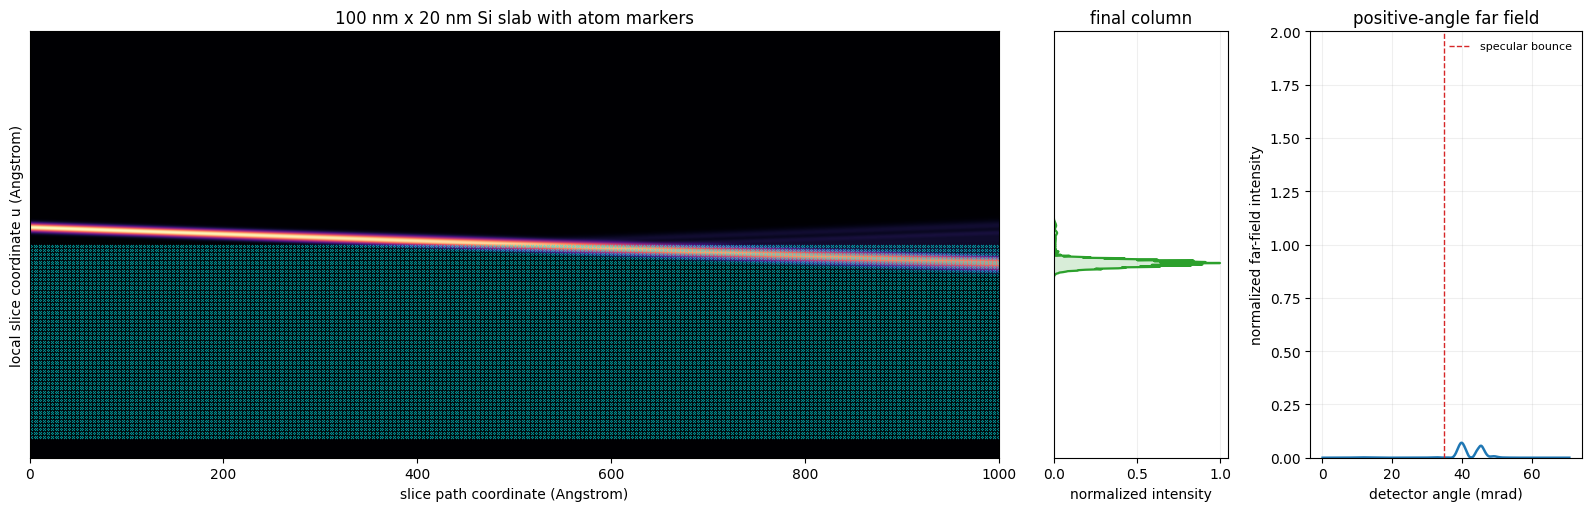

: 

In [ ]:
intensity = np.asarray(wavefront_intensity)
intensity_display = np.sqrt(intensity / (intensity.max() + 1e-30))
output_intensity = np.asarray(jnp.abs(fresnel_wave) ** 2)
output_intensity = output_intensity / (output_intensity.max() + 1e-30)
farfield_detector = np.asarray(full_exit_farfield)
farfield_detector = farfield_detector / (farfield_detector.max() + 1e-30)

extent = [
    float(slice_axis[0]),
    float(slice_axis[-1] + path_step),
    float(u[0]),
    float(u[-1]),
]

from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots(figsize=(15.8, 5.2), constrained_layout=True)
ax.imshow(
    intensity_display.T,
    extent=extent,
    origin="lower",
    aspect="equal",
    cmap="magma",
    vmin=0.0,
    vmax=1.0,
)
ax.scatter(
    atom_marker_s,
    atom_marker_u,
    s=1.0,
    c="cyan",
    alpha=0.55,
    linewidths=0,
    rasterized=True,
)

ax.set_xlabel("slice path coordinate (Angstrom)")
ax.set_ylabel("local slice coordinate u (Angstrom)")
ax.set_aspect("equal", adjustable="box")
ax.set_title(f"{slab_width_nm:.0f} nm x {slab_depth_nm:.0f} nm Si slab with atom markers")

# The final-column panel is real-space intensity; the far-field panel is the full exit wave collected only on the bounced side.
divider = make_axes_locatable(ax)
ax_out = divider.append_axes("right", size="18%", pad=0.55, sharey=ax)
ax_det = divider.append_axes("right", size="28%", pad=0.82)

ax_out.plot(output_intensity, np.asarray(u), color="tab:green", lw=1.6)
ax_out.fill_betweenx(np.asarray(u), 0.0, output_intensity, color="tab:green", alpha=0.18)
ax_out.set_xlabel("normalized intensity")
ax_out.set_title("final column")
ax_out.set_xlim(0.0, 1.05)
ax_out.set_yticks([])
ax_out.grid(alpha=0.2)

positive_angle_mask = detector_angle_mrad > 0.0
ax_det.plot(
    detector_angle_mrad[positive_angle_mask],
    farfield_detector[positive_angle_mask] + 1e-12,
    color="tab:blue",
    lw=1.8,
)
ax_det.axvline(bounced_angle_mrad, color="tab:red", lw=1.0, ls="--", label="specular bounce")
ax_det.set_xlabel("detector angle (mrad)")
ax_det.set_ylabel("normalized far-field intensity")
ax_det.set_title("positive-angle far field")
ax_det.set_ylim(1e-10, 2.0)
ax_det.grid(alpha=0.2)
ax_det.legend(loc="upper right", fontsize=8, frameon=False)

plt.show()
